In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pytensor
import arviz as az
import tabulate
pytensor.config.cxx = '/usr/bin/clang++'

# Import Data

In [2]:
#function to clean data from game logs
def get_data(filename, groupname):
    df = pd.read_csv(filename, header = None)
    home_teams = df.iloc[:,[0,6,8,53]]
    away_teams = df.iloc[:,[0,3,5,25]]
    home_teams = home_teams.rename({0:'Date',6:'Team',8:'Game_Num',53:'HR'},axis = 1)
    away_teams = away_teams.rename({0:'Date',3:'Team',5:'Game_Num',25:'HR'},axis = 1)
    games = pd.concat([home_teams,away_teams],ignore_index=True)
    games = games[games["Team"]=="CLE"]
    games.loc[:,"Group"] = groupname
    return games

In [3]:
#run functions for 2024 and 2025
Guards_2025 = get_data('gl2025.txt', '2025 - Full Season')
Guards_2024 = get_data('gl2024.txt', '2024 - Full Season')

#subset of first 42 games of 2025, used for mid-season prediction
Guards_First42 = Guards_2025[Guards_2025["Game_Num"]<=42]
Guards_First42.loc[:,"Group"] = "2025 - First 42 Games"

# Plots

Text(0, 0.5, 'Games')

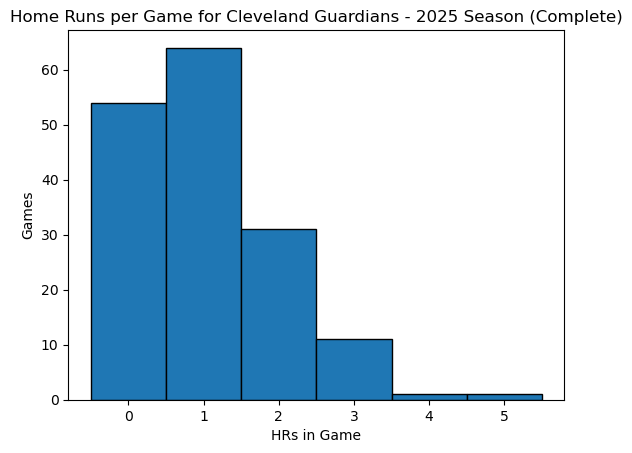

In [4]:
#2025 Full Season HR Histogram
plt.hist(Guards_2025["HR"], align = 'left', bins =  np.arange(0, Guards_2025["HR"].max() + 2),edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians - 2025 Season (Complete)")
plt.xlabel("HRs in Game")
plt.ylabel("Games")

Text(0.5, 0, 'HRs in Game')

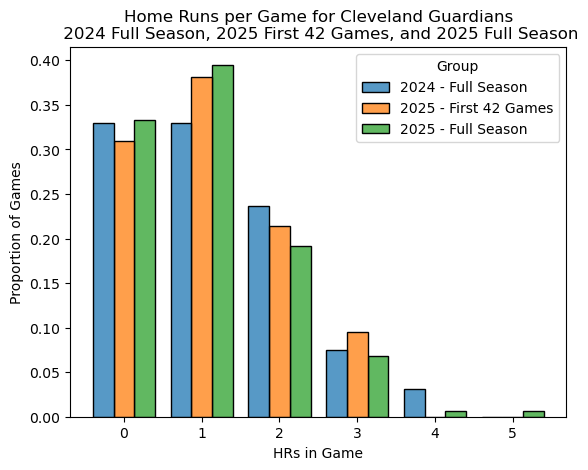

In [5]:
# Combined histogram for each group
df = pd.concat([Guards_2024,Guards_First42,Guards_2025],ignore_index=True)
sns.histplot(data = df, x = "HR", stat = "probability",hue = "Group", common_norm = False, multiple = "dodge", shrink = 0.8, bins = np.arange(-0.5, df["HR"].max() + 1.5), edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians\n 2024 Full Season, 2025 First 42 Games, and 2025 Full Season")
plt.ylabel("Proportion of Games")
plt.xlabel("HRs in Game")

In [6]:
#summary statistics
summary_stats = df.groupby("Group")["HR"].agg(['mean','std'])
summary_stats

,mean,std
Group,,
2024 - Full Season,1.149068,1.061904
2025 - First 42 Games,1.095238,0.957882
2025 - Full Season,1.037037,0.977313


Text(0.5, 0, 'HRs in Game')

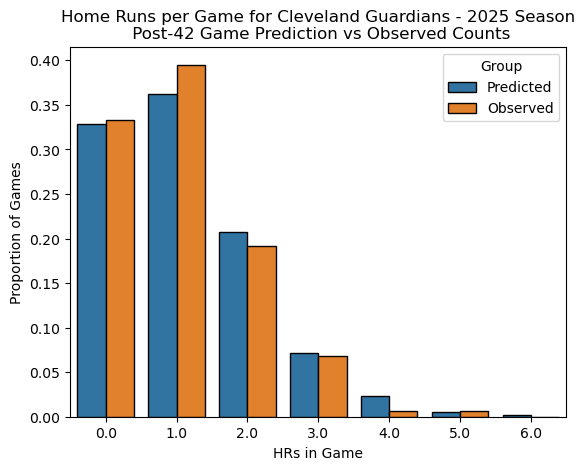

In [7]:
#prediction vs full-season observation comparison

#predicted 2025 proportions for HR per game
proportions = [.328,.36225,.20775,.072,.023,.00525,.00175]
Pred_Eval = pd.DataFrame(data = [[0,1,2,3,4,5,6],proportions]).T.rename({0:'HR',1:'Predicted'},axis = 1)

#observed 2025 proportions for HR per game, melt into one dataframe
Pred_Eval.loc[:,"Observed"] = Guards_2025["HR"].value_counts().sort_index().reindex(Pred_Eval["HR"], fill_value = 0).values / 162
Pred_Eval = Pred_Eval.melt(id_vars = ['HR'], value_vars = ['Predicted','Observed'], var_name = 'Group', value_name = 'Count')

#plot
sns.barplot(data = Pred_Eval, x = "HR", y = "Count", hue = "Group", edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians - 2025 Season\n Post-42 Game Prediction vs Observed Counts")
plt.ylabel("Proportion of Games")
plt.xlabel("HRs in Game")

In [8]:
#PyMC model for HR rate based on full season
basic_model = pm.Model()
with basic_model:

    #lambda = poisson rate with Gamma(16,14) prior
    lambdah = pm.Gamma("lambdah",alpha = 16, beta = 14)

    # number of HRs per game observed assuming Poisson distribution with rate lambda
    Y_obs = pm.Poisson("Y_obs",mu = lambdah,observed = Guards_2025.loc[:,"HR"])

    #sample
    idata = pm.sample(random_seed=17)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambdah]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [9]:
#summary of posterior for HR rate
pm.summary(idata,var_names=["lambdah"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambdah,1.047,0.078,0.9,1.198,0.002,0.001,1550.0,2578.0,1.0


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/var/folders/1m/2cvqlb513n55bnylj8wfd48c0000gn/T/ipykernel_51400/1564887137.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Simulated Posterior Distribution of Home Run Poisson Rate ($\lambda$)\nUsing Gamma(16,14) Prior")


Text(0.5, 1.0, 'Simulated Posterior Distribution of Home Run Poisson Rate ($\\lambda$)\nUsing Gamma(16,14) Prior')

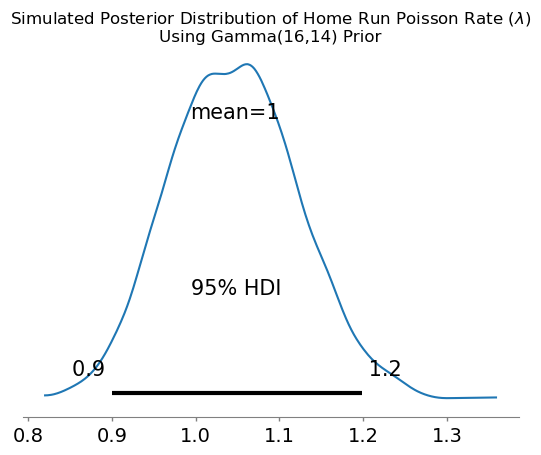

In [10]:
#posterior trace plot
az.plot_posterior(idata,var_names=["lambdah"],hdi_prob = .95)
plt.title(f"Simulated Posterior Distribution of Home Run Poisson Rate ($\lambda$)\nUsing Gamma(16,14) Prior")